In [1]:
import numpy as np
import matplotlib.pyplot as pl
import scipy as sp
import scipy.sparse.linalg
#from numba import jit
from matplotlib import cm

pl.rcParams['mathtext.fontset'] = 'cm'
pl.rcParams['font.family'] = 'serif' # or 'sans-serif' or 'monospace'
pl.rcParams['font.serif'] = 'cmr10'
pl.rcParams['font.sans-serif'] = 'cmss10'
pl.rcParams['font.monospace'] = 'cmtt10'
pl.rcParams["axes.formatter.use_mathtext"] = True # to fix the minus signs
pl.rcParams['font.size'] = 22

In [2]:
g = 1


def V(x,v1,v2,M,N,phi):
    return v1*np.cos(2*x)+v2*np.cos(2*M/N*x+phi)


def GPE1D(psi,mu,hx,nx,pot):

    gradient = np.zeros(nx)
    gradient[1:-1] = -1/(2*hx**2)*(psi[:-2]-2*psi[1:-1]+psi[2:])
    gradient[0] = -1/(2*hx**2)*(psi[-1]-2*psi[0]+psi[1])
    gradient[-1] = -1/(2*hx**2)*(psi[-2]-2*psi[-1]+psi[0])
    function = gradient - mu*psi + g*psi**3 + pot*psi
    return function


def espetro(nx,M,N,v1,v2,phi,niveis):
    xx = np.linspace(-np.pi*N/2,np.pi*N/2,nx+1)
    hx = xx[1]-xx[0]
    
    potential = V(xx[:-1],v1,v2,M,N,phi)
    
    diagonal1 = -1/(2*hx**2)*np.ones(nx-1)
    diagonal = potential+1/hx**2
    fronteira = -1/(2*hx**2)
    diagonals = [diagonal,diagonal1,diagonal1,fronteira,fronteira]
        
    J = sp.sparse.diags(diagonals,(0,1,-1,nx-1,-nx+1),(nx,nx),'csr') 
    
    values, vectors = scipy.sparse.linalg.eigs(J,niveis,which='SM')
    
    return xx[:-1],values,vectors,phi

#@jit
def newtonquasi(nx,M,N,v1,v2,phi,eps,mu,psi):
    xx = np.linspace(-np.pi*N/2,np.pi*N/2,nx+1)
    hx = xx[1]-xx[0]

    potential = V(xx[:-1],v1,v2,M,N,phi)
    dpsi = np.ones(nx)
    
    diagonal1 = -1/(2*hx**2)*np.ones(nx-1)
    fronteira = -1/(2*hx**2)
    
    while abs(np.linalg.norm(dpsi)) > eps:
        diagonal = -mu+potential+3*g*psi**2+1/hx**2
        diagonals = [diagonal,diagonal1,diagonal1,fronteira,fronteira]
        
        J = sp.sparse.diags(diagonals,(0,1,-1,nx-1,-nx+1),(nx,nx),'csr')
        
        dpsi = sp.sparse.linalg.spsolve(J,-GPE1D(psi,mu,hx,nx,potential))
        psi += dpsi
         
    return xx[:-1],psi,potential 

#@jit
def varrimento(nx,M,N,v1,v2,phi,eps,mu,psi,it):
    
    estados = np.zeros([nx,it])
    potenciais = np.zeros(it)
    
    for i in range(it):
        estados[:,i] = psi
        potenciais[i] = mu
    
        print(i)
        
        #mu -= 10**(-6)
        #mu += 5*10**(-5)
        mu += 10**(-4)
        
        xx,onda,potencial = newtonquasi(nx,M,N,v1,v2,phi,eps,mu,psi)
        psi = onda
        
    return estados,potenciais

#@jit
def bdgennes(nx,M,N,v1,v2,phi,psig,mug,niveis):
    
    xx = np.linspace(-np.pi*N/2,np.pi*N/2,nx+1)
    hx = xx[1]-xx[0]
    
    potential = V(xx[:-1],v1,v2,M,N,phi)
    
    diagonal1 = np.zeros(2*nx-1)
    diagonal1[0:nx-1] = -1/(2*hx**2)
    diagonal1[nx:] = 1/(2*hx**2)
    diagonal = np.concatenate((1/hx**2+potential-mug+2*g*psig**2,-1/hx**2-potential+mug-2*g*psig**2))
    
    fronteira = np.zeros(nx+1)
    fronteira[0] = -1/(2*hx**2)
    fronteira[-1] = 1/(2*hx**2)
    
    nonlinear = g*psig**2
    nonlinearc = g*psig**2
    diagonals = [diagonal,diagonal1,diagonal1,fronteira,fronteira,-nonlinear,nonlinearc]
        
    J = sp.sparse.diags(diagonals,(0,1,-1,nx-1,-nx+1,nx,-nx),(2*nx,2*nx),'csr') 
    
    #values, vectors = scipy.sparse.linalg.eigs(J,niveis,sigma=0)
    values, vectors = scipy.sparse.linalg.eigs(J,niveis,which = 'SR')
    
    return xx[:-1],values,vectors,phi

def evolucao(t,num,nx,M,N,v1,v2,phi,psi0):
    dt = t/num 
    xx = np.linspace(-np.pi*N/2,np.pi*N/2,nx+1)
    hx = xx[1]-xx[0]
    
    potential = V(xx[:-1],v1,v2,M,N,phi)
    #history = np.zeros([num,nx],dtype=complex)
    
    #modulos = np.zeros(num)
    
    psi = psi0 
    
    normalizar0 = psi0.real**2+psi0.imag**2

    const0 = (hx/3) * (normalizar0[0] + 2*sum(normalizar0[:nx-2:2]) + 4*sum(normalizar0[1:nx-1:2]) + normalizar0[nx-1])
    
    diagonalq = 2*(2*hx**2*1j-dt)/dt*np.ones(nx)
    diagonalq1 = np.ones(nx-1)
    fronteira = 1
    diagonalsq = [diagonalq,diagonalq1,diagonalq1,fronteira,fronteira]
    
    
    Q = sp.sparse.diags(diagonalsq,(0,1,-1,nx-1,-nx+1),(nx,nx),'csr')
    
    #for tempo in range(num):
        
    #history[tempo] = psi
    
    diagonal1 = -1*np.ones(nx-1)
    fronteira = -1        
    diagonal = 2*(1+(2*hx**2*1j/dt)+2*hx**2*potential+2*hx**2*g*(psi.real**2+psi.imag**2))
        
    diagonals = [diagonal,diagonal1,diagonal1,fronteira,fronteira]
        
    H = sp.sparse.diags(diagonals,(0,1,-1,nx-1,-nx+1),(nx,nx),'csr')
        
    vetor = H@psi
        
    psi = sp.sparse.linalg.spsolve(Q,vetor)
        
    normalizar = psi.real**2+psi.imag**2

    const = (hx/3) * (normalizar[0] + 2*sum(normalizar[:nx-2:2]) + 4*sum(normalizar[1:nx-1:2]) + normalizar[nx-1])
    
    psi = psi*np.sqrt(const0/const)
    
    #modulos[tempo] = const
        
    return psi,const0

def GPE(psi,hx,nx,pot):

    gradient = np.zeros(nx)
    gradient[1:-1] = -1/(2*hx**2)*(psi[:-2]-2*psi[1:-1]+psi[2:])
    gradient[0] = -1/(2*hx**2)*(psi[-1]-2*psi[0]+psi[1])
    gradient[-1] = -1/(2*hx**2)*(psi[-2]-2*psi[-1]+psi[0])
    function = gradient + g*(psi.real**2+2*psi.real*psi.imag+psi.imag**2)*psi + pot*psi
    return function
 

# Split-step Fourier method
def evolve(t,num,nx,M,N,v1,v2,phi,psi):
    
    dt = t/num 
    xx = np.linspace(-np.pi*N/2,np.pi*N/2,nx+1)
    hx = xx[1]-xx[0]
    
    potential = V(xx[:-1],v1,v2,M,N,phi)
    
    # Fourier space wavevector (corresponding to periodic boundary conditions)
    kx = np.fft.fftfreq(nx, hx) * 2 * np.pi  # FFT frequency grid
    kx = np.fft.fftshift(kx)  # Shift the grid to center around 0

    # Potential in Fourier space (this will only have real values)
    V_k = np.fft.fftshift(np.fft.fft(potential))

    
    # Step 1: Propagate in momentum space (due to kinetic term)
    psi_k = np.fft.fft(psi)
    kinetic = np.exp(-1j * kx**2 * dt / (2 * m))  # Kinetic evolution operator
    psi_k = psi_k * kinetic
    
    # Step 2: Propagate in real space (due to potential + nonlinearity)
    psi = np.fft.ifft(psi_k)  # Inverse FFT to real space
    nonlinear = np.exp(-1j * g * np.abs(psi)**2 * dt)  # Nonlinear evolution operator
    psi = psi * nonlinear

    # Step 3: Propagate again in momentum space (due to potential term)
    psi_k = np.fft.fft(psi)  # FFT to momentum space
    psi_k = psi_k * np.exp(-1j * V_k * dt)  # Potential in Fourier space
    
    # Step 4: Return to real space
    psi = np.fft.ifft(psi_k)  # Inverse FFT to real space
    return psi

def time_step2(t, num_steps, nx, M, N, v1, v2, phi, psi):
    dt = t / num_steps
    
    # Spatial grid (periodic, excluding endpoint)
    xx = np.linspace(-np.pi*N/2, np.pi*N/2, nx, endpoint=False)
    dx = xx[1] - xx[0]
    
    potential = V(xx, v1, v2, M, N, phi)
    
    # Fourier space setup
    kx = 2 * np.pi * np.fft.fftfreq(nx, dx)
    k_squared = kx**2
    
    # Pre-compute evolution operators
    exp_K_half = np.exp(-0.5j * k_squared * dt)  # Half kinetic step
    exp_V = np.exp(-1j * dt * potential)  # Potential part
    
    #for _ in range(num_steps):
        # Split-step Fourier method (symmetric)
        
        # 1. Half kinetic step in Fourier space
    psi = ifft(exp_K_half * fft(psi))
        
        # 2. Full potential + nonlinear step in real space
    psi = exp_V * np.exp(-1j * dt * g * np.abs(psi)**2) * psi
        
        # 3. Half kinetic step in Fourier space
    psi = ifft(exp_K_half * fft(psi))
        
        # Optional: Renormalize to preserve particle number
        # norm = np.sqrt(np.sum(np.abs(psi)**2) * dx)
        # psi /= norm
    
    return psi

In [3]:
nx = 5000
M = 233
N = 144
v1 = 0.8
v2 = 0.1
fase = -np.sqrt(2)

In [4]:
#g=1 e delta mu +10**-4


xx,vlinear3,psilinear3,phi = espetro(nx,M,N,v1,v2,fase,300)
hx = xx[1]-xx[0]

potential = V(xx,v1,v2,M,N,phi)
    
#indice = np.argmin(vlinear3)
indice = np.ravel(np.where(vlinear3 == sorted(vlinear3)[53]))[0]
    
mu = vlinear3[indice].real
psi = psilinear3[:,indice]

normalizar = psilinear3[:,indice]**2

const = (hx/3) * (normalizar[0] + 2*sum(normalizar[:nx-2:2]) + 4*sum(normalizar[1:nx-1:2]) + normalizar[nx-1])

estados3,potenciais3 = varrimento(nx,M,N,v1,v2,fase,10**(-6),mu,psi/np.sqrt(const),1000)

/tmp/ipykernel_54487/2956374275.py:64: ComplexWarning: Casting complex values to real discards the imaginary part
  estados[:,i] = psi
/tmp/ipykernel_54487/2956374275.py:11: ComplexWarning: Casting complex values to real discards the imaginary part
  gradient[1:-1] = -1/(2*hx**2)*(psi[:-2]-2*psi[1:-1]+psi[2:])
/tmp/ipykernel_54487/2956374275.py:12: ComplexWarning: Casting complex values to real discards the imaginary part
  gradient[0] = -1/(2*hx**2)*(psi[-1]-2*psi[0]+psi[1])
/tmp/ipykernel_54487/2956374275.py:13: ComplexWarning: Casting complex values to real discards the imaginary part
  gradient[-1] = -1/(2*hx**2)*(psi[-2]-2*psi[-1]+psi[0])


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

In [5]:
nbdg = 9998

xx,valuesa,vectorsa,phi = bdgennes(nx,M,N,v1,v2,fase,estados3[:,30],potenciais3[30],nbdg)

print(max(valuesa.imag))

participacao = np.zeros(nbdg)
norm = np.zeros(nbdg)

participacaou = np.zeros(nbdg)
normu = np.zeros(nbdg)
participacaov = np.zeros(nbdg)
normv = np.zeros(nbdg)


hx = xx[1]-xx[0]
ht = xx[1]-xx[0]

for n,m in enumerate(sorted(valuesa.real)):
    nivel = np.ravel(np.where(valuesa.real==(m)))
    
    u = vectorsa[0:nx,nivel[0]]
    v = vectorsa[nx:,nivel[0]]
    
    u2 = u.real**2+u.imag**2
    v2 = v.real**2+v.imag**2
    
    onda = u - v
    
    psi = (onda.real**2+onda.imag**2)
    
    natomsu = (ht/3) * (u2[0] + 2*sum(u2[:nx-2:2]) + 4*sum(u2[1:nx-1:2]) + u2[nx-1])
    natomsv = (ht/3) * (v2[0] + 2*sum(v2[:nx-2:2]) + 4*sum(v2[1:nx-1:2]) + v2[nx-1])
    
    iprsu = (u.real**4+2*u.real**2*u.imag**2+u.imag**4)
    iprsv = (v.real**4+2*v.real**2*v.imag**2+v.imag**4)
    
    ipru = (1/natomsu**2)*(ht/3)*(iprsu[0] + 2*sum(iprsu[:nx-2:2]) + 4*sum(iprsu[1:nx-1:2]) + iprsu[nx-1])
    iprv = (1/natomsv**2)*(ht/3)*(iprsv[0] + 2*sum(iprsv[:nx-2:2]) + 4*sum(iprsv[1:nx-1:2]) + iprsv[nx-1])
    
    
    natoms = (ht/3) * (psi[0] + 2*sum(psi[:nx-2:2]) + 4*sum(psi[1:nx-1:2]) + psi[nx-1])
    
    iprs = (onda.real**4+2*onda.real**2*onda.imag**2+onda.imag**4)
    
    ipr = (1/natoms**2)*(ht/3)*(iprs[0] + 2*sum(iprs[:nx-2:2]) + 4*sum(iprs[1:nx-1:2]) + iprs[nx-1])
    
    participacao[n] = ipr
    norm[n] = natoms
    

    participacaou[n] = ipru
    normu[n] = natomsu
    participacaov[n] = iprv
    normv[n] = natomsv

4.868114127539689e-05


In [83]:
#indice = np.ravel(np.where(vlinear3 == sorted(vlinear3)[53]))[0]
ondabc = estados3[:,0]
psibc = (ondabc.real**2+ondabc.imag**2)
    

natomsbc = (ht/3) * (psibc[0] + 2*sum(psibc[:nx-2:2]) + 4*sum(psibc[1:nx-1:2]) + psibc[nx-1])
    
iprsbc = (ondabc.real**4+2*ondabc.real**2*ondabc.imag**2+ondabc.imag**4)
    
iprbc = (1/natomsbc**2)*(ht/3)*(iprsbc[0] + 2*sum(iprsbc[:nx-2:2]) + 4*sum(iprsbc[1:nx-1:2]) + iprsbc[nx-1])

print(r'$\tilde{\chi_{55}}$=',iprbc)
print(r'$\chi_u$=',participacaou[4856])
print(r'$\chi_v$=',participacaov[4856])

$\tilde{\chi_{55}}$= 0.006972076036221524
$\chi_u$= 0.06464313079341265
$\chi_v$= 0.026877486061872936


In [ ]:
#onda = np.loadtxt('perturbacao54',dtype=complex)
onda = np.loadtxt('perturbacao89',dtype=complex)

<>:11: SyntaxWarning: invalid escape sequence '\p'
<>:11: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_54487/3817406326.py:11: SyntaxWarning: invalid escape sequence '\p'
  ax1.set_ylabel('$\psi$')


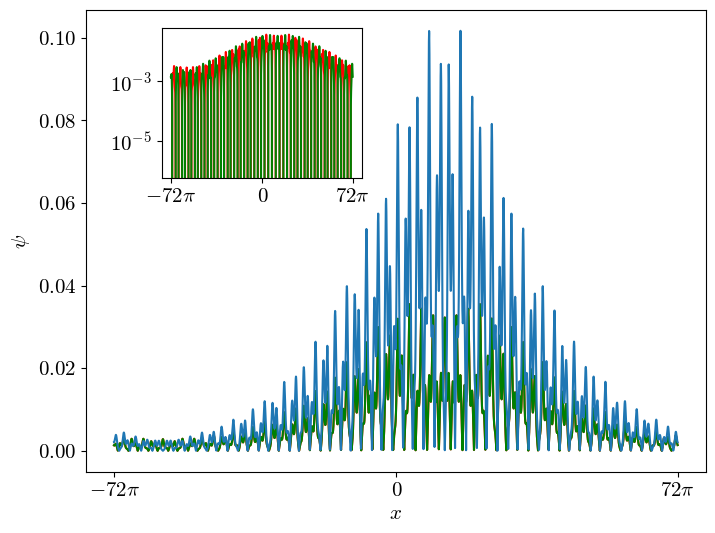

In [50]:
indice = np.ravel(np.where(valuesa.real==sorted(valuesa.real)[5000]))[0]

barras=(-72*np.pi,0,72*np.pi)
labels=(r'$-72\pi$','0',r'$72\pi$')

fig, ax1 = pl.subplots(figsize=[8,6])
left, bottom, width, height = [0.22, 0.6, 0.25, 0.25]
ax2 = fig.add_axes([left, bottom, width, height])

ax1.set_xlabel('$x$')
ax1.set_ylabel('$\psi$')
ax1.set_xticks(barras,labels)

ax1.plot(xx,abs(vectorsa[0:nx,indice]),color='red')
ax1.plot(xx,abs(vectorsa[nx:,indice]),color='green')
ax1.plot(xx,abs(estados3[:,30]))

ax2.set_xticks(barras,labels)
ax2.set_yscale('log')


ax2.plot(xx,vectorsa[0:nx,indice],color='red')
ax2.plot(xx,vectorsa[nx:,indice],color='green')


pl.show()

In [107]:
redd = vectorsa[0:nx,indice]
greenn = vectorsa[nx:,indice]

psiredd = redd.real**2+redd.imag**2
psigreenn = greenn.real**2+greenn.imag**2
natomsredd = (ht/3) * (psiredd[0] + 2*sum(psiredd[:nx-2:2]) + 4*sum(psiredd[1:nx-1:2]) + psiredd[nx-1])
natomsgreenn = (ht/3) * (psigreenn[0] + 2*sum(psigreenn[:nx-2:2]) + 4*sum(psigreenn[1:nx-1:2]) + psigreenn[nx-1])
centroredd = xx*psiredd
centrogreenn = xx*psigreenn
x2redd = xx**2*psiredd
x2greenn = xx**2*psigreenn
centrosredd = (1/natomsredd)*(ht/3)*(centroredd[0] + 2*sum(centroredd[:nx-2:2]) + 4*sum(centroredd[1:nx-1:2]) + centroredd[nx-1])
centrosgreenn = (1/natomsgreenn)*(ht/3)*(centrogreenn[0] + 2*sum(centrogreenn[:nx-2:2]) + 4*sum(centrogreenn[1:nx-1:2]) + centrogreenn[nx-1])
xx2redd = (1/natomsredd**2)*(ht/3)*(x2redd[0] + 2*sum(x2redd[:nx-2:2]) + 4*sum(x2redd[1:nx-1:2]) + x2redd[nx-1])
xx2greenn = (1/natomsgreenn**2)*(ht/3)*(x2greenn[0] + 2*sum(x2greenn[:nx-2:2]) + 4*sum(x2greenn[1:nx-1:2]) + x2greenn[nx-1])

print(np.sqrt(xx2redd-centrosredd**2),np.sqrt(xx2greenn-centrosgreenn**2))

138.6571630365409 7459.576168009879


<>:14: SyntaxWarning: invalid escape sequence '\p'
<>:30: SyntaxWarning: invalid escape sequence '\p'
<>:33: SyntaxWarning: invalid escape sequence '\p'
<>:41: SyntaxWarning: invalid escape sequence '\p'
<>:44: SyntaxWarning: invalid escape sequence '\p'
<>:14: SyntaxWarning: invalid escape sequence '\p'
<>:30: SyntaxWarning: invalid escape sequence '\p'
<>:33: SyntaxWarning: invalid escape sequence '\p'
<>:41: SyntaxWarning: invalid escape sequence '\p'
<>:44: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_24362/221903419.py:14: SyntaxWarning: invalid escape sequence '\p'
  subfigs[0].set_ylabel('$\psi$')
/tmp/ipykernel_24362/221903419.py:30: SyntaxWarning: invalid escape sequence '\p'
  subfigs[1].set_ylabel('$\psi$')
/tmp/ipykernel_24362/221903419.py:33: SyntaxWarning: invalid escape sequence '\p'
  subfigs[1].set_ylabel('$\psi$')
/tmp/ipykernel_24362/221903419.py:41: SyntaxWarning: invalid escape sequence '\p'
  subfigs[2].set_ylabel('$\psi$')
/tmp/ipykernel_24362/22190

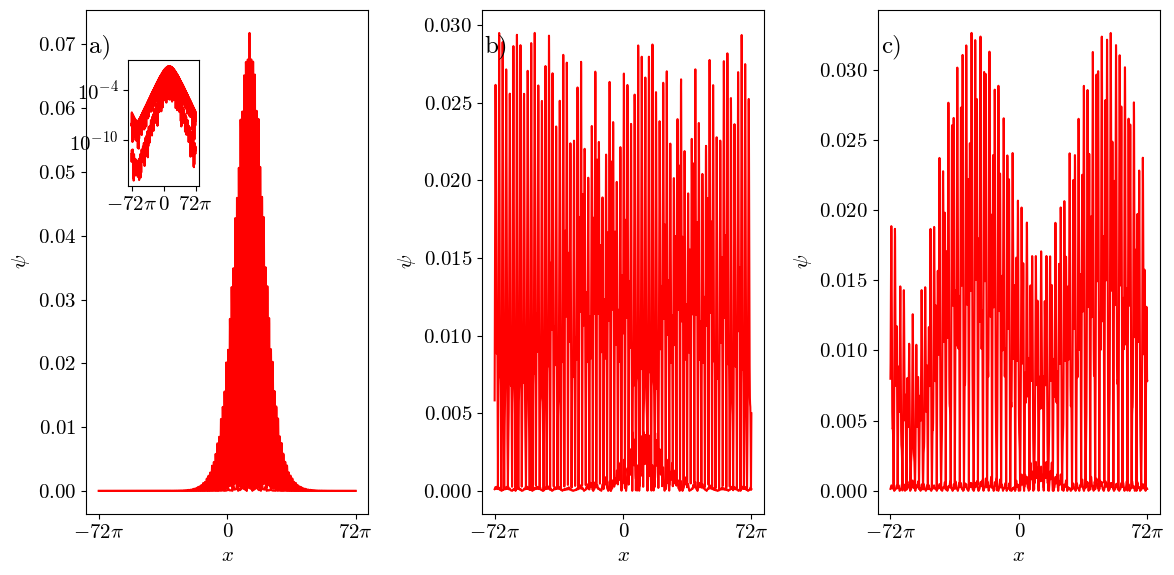

In [18]:
indice1 = np.ravel(np.where(valuesa.real==sorted(valuesa.real)[4856]))[0]
indice2 = np.ravel(np.where(valuesa.real==sorted(valuesa.real)[4950]))[0]
indice3 = np.ravel(np.where(valuesa.real==sorted(valuesa.real)[4990]))[0]
barras=(-72*np.pi,0,72*np.pi)
labels=(r'$-72\pi$','0',r'$72\pi$')

fig = pl.figure(figsize=[12,6])

subfigs = fig.subplots(1,3)

subfigs[0].set_title("a)", x=0.05, y=0.9)
inset = subfigs[0].inset_axes([0.15, 0.65, 0.25, 0.25])
subfigs[0].set_xlabel('$x$')
subfigs[0].set_ylabel('$\psi$')
subfigs[0].set_xticks(barras,labels)

subfigs[0].plot(xx,abs(vectorsa[0:nx,indice1]),color='red')
subfigs[0].plot(xx,abs(vectorsa[nx:,indice1]),color='red')


inset.set_xticks(barras,labels)
inset.set_yscale('log')


inset.plot(xx,abs(vectorsa[0:nx,indice1]),color='red')
inset.plot(xx,abs(vectorsa[nx:,indice1]),color='red')

subfigs[1].set_title("b)", x=0.05, y=0.9)
subfigs[1].set_xlabel('$x$')
subfigs[1].set_ylabel('$\psi$')
subfigs[1].set_xticks(barras,labels)
subfigs[1].set_xlabel('$x$')
subfigs[1].set_ylabel('$\psi$')


subfigs[1].plot(xx,abs(vectorsa[0:nx,indice2]),color='red')
subfigs[1].plot(xx,abs(vectorsa[nx:,indice2]),color='red')

subfigs[2].set_title("c)", x=0.05, y=0.9)
subfigs[2].set_xlabel('$x$')
subfigs[2].set_ylabel('$\psi$')
subfigs[2].set_xticks(barras,labels)
subfigs[2].set_xlabel('$x$')
subfigs[2].set_ylabel('$\psi$')


subfigs[2].plot(xx,abs(vectorsa[0:nx,indice3]),color='red')
subfigs[2].plot(xx,abs(vectorsa[nx:,indice3]),color='red')

pl.tight_layout()
pl.show()

4856
4857
4911
5088
5142
5143


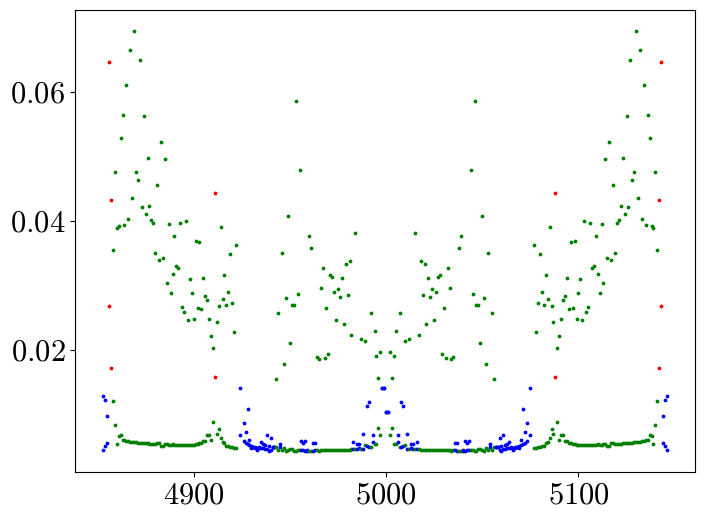

In [9]:
pl.figure(figsize=[8,6])
#pl.ylim(0,0.075)

deslocalizados = []
ulocalizado = []
vlocalizado = []
localizados = []

for i in range(4750,5250):
    if participacaou[i] > 0.015:
        if participacaov[i] > 0.015:
            pl.scatter(i,participacaou[i],color='red',s=3)
            pl.scatter(i,participacaov[i],color='red',s=3)
            print(i)
            localizados.append(i)
        elif normu[i] > 10**(-6):
            pl.scatter(i,participacaou[i],color='green',s=3)
            pl.scatter(i,participacaov[i],color='green',s=3)
            ulocalizado.append(i)
    elif participacaov[i] > 0.015: 
        if normv[i] > 10**(-6):
            pl.scatter(i,participacaou[i],color='green',s=3)
            pl.scatter(i,participacaov[i],color='green',s=3)
            vlocalizado.append(i)
    else:
        pl.scatter(i,participacaou[i],color='blue',s=3)
        pl.scatter(i,participacaov[i],color='blue',s=3)
        deslocalizados.append(i)

<>:5: SyntaxWarning: invalid escape sequence '\c'
<>:5: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_24362/315324556.py:5: SyntaxWarning: invalid escape sequence '\c'
  pl.ylabel('$\chi$')


4856
4857
4911
5088
5142
5143


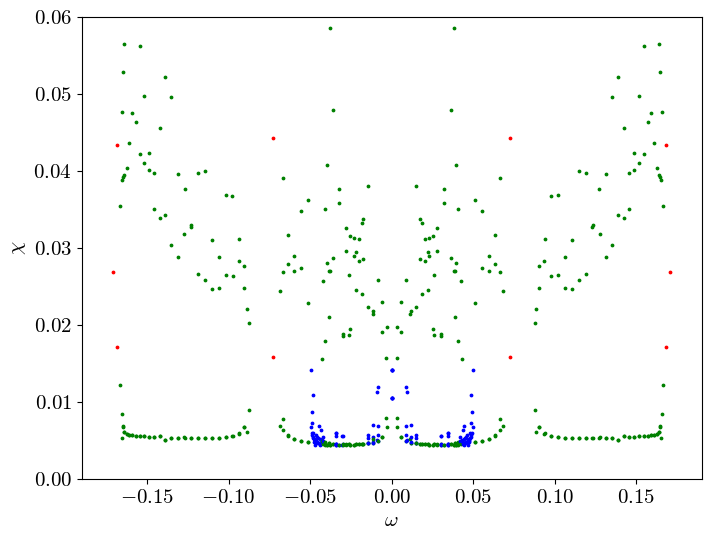

In [28]:
pl.figure(figsize=[8,6])
pl.ylim(0,0.06)
pl.xlim(-0.19,0.19)
pl.xlabel(r'$\omega$')
pl.ylabel('$\chi$')

deslocalizados = []
ulocalizado = []
vlocalizado = []
localizados = []

for i in range(4500,5500):
    if participacaou[i] > 0.015:
        if participacaov[i] > 0.015:
            pl.scatter(sorted(valuesa)[i],participacaou[i],color='red',s=3)
            pl.scatter(sorted(valuesa)[i],participacaov[i],color='red',s=3)
            print(i)
            localizados.append(i)
        elif normu[i] > 10**(-6):
            pl.scatter(sorted(valuesa)[i],participacaou[i],color='green',s=3)
            pl.scatter(sorted(valuesa)[i],participacaov[i],color='green',s=3)
            ulocalizado.append(i)
    elif participacaov[i] > 0.015: 
        if normv[i] > 10**(-6):
            pl.scatter(sorted(valuesa)[i],participacaou[i],color='green',s=3)
            pl.scatter(sorted(valuesa)[i],participacaov[i],color='green',s=3)
            vlocalizado.append(i)
    else:
        pl.scatter(sorted(valuesa)[i],participacaou[i],color='blue',s=3)
        pl.scatter(sorted(valuesa)[i],participacaov[i],color='blue',s=3)
        deslocalizados.append(i)

[9473]
[9478]
[9479]
[9553]
[9715]
[9805]
[9822]
[9908]
[9920]
[9951]
[9949]


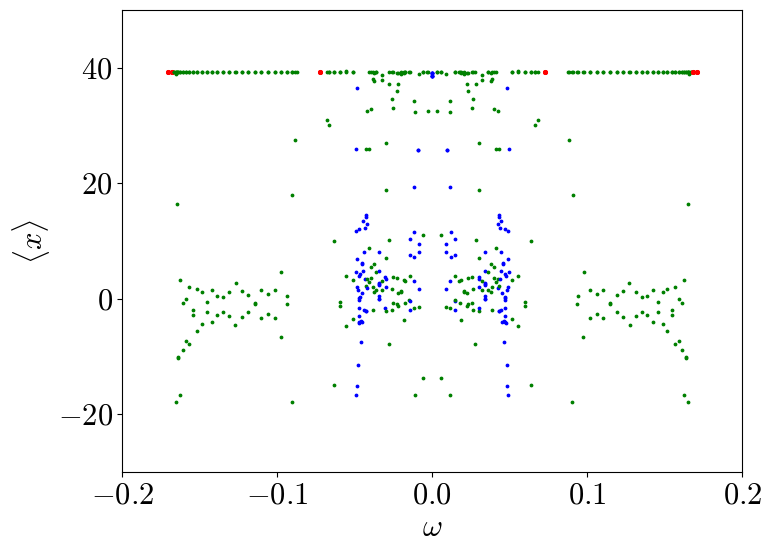

In [21]:
pl.rcParams['font.size'] = 22
pl.figure(figsize=[8,6],dpi=100)
pl.xlabel(r'$\omega$')
pl.ylabel(r'$\langle x \rangle$')
pl.xlim(-0.2,0.2)
pl.ylim(-30,50)
indice = 4750
for i,j in enumerate(sorted(valuesa.real)[4750:5250]):
    nivel = np.ravel(np.where(valuesa==(sorted(valuesa)[indice])))
    u = vectorsa[0:nx,nivel[0]]
    v = vectorsa[nx:,nivel[0]]
    psiu = u.real**2+u.imag**2
    psiv = v.real**2+v.imag**2
    natomsu = (ht/3) * (psiu[0] + 2*sum(psiu[:nx-2:2]) + 4*sum(psiu[1:nx-1:2]) + psiu[nx-1])
    natomsv = (ht/3) * (psiv[0] + 2*sum(psiv[:nx-2:2]) + 4*sum(psiv[1:nx-1:2]) + psiv[nx-1])
    centrou = xx*psiu
    centrov = xx*psiv
    centrosu = (1/natomsu)*(ht/3)*(centrou[0] + 2*sum(centrou[:nx-2:2]) + 4*sum(centrou[1:nx-1:2]) + centrou[nx-1])
    centrosv = (1/natomsv)*(ht/3)*(centrov[0] + 2*sum(centrov[:nx-2:2]) + 4*sum(centrov[1:nx-1:2]) + centrov[nx-1])
    if centrosv < -20:
        print(nivel)
    if indice in localizados:
        pl.scatter(j,centrosu,color='red',s=7)
        pl.scatter(j,centrosv,color='red',s=7)
    elif indice in ulocalizado:
        pl.scatter(j,centrosu,color='green',s=3)
        pl.scatter(j,centrosv,color='green',s=3)
    elif indice in vlocalizado:
        pl.scatter(j,centrosu,color='green',s=3)
        pl.scatter(j,centrosv,color='green',s=3)
    elif indice in deslocalizados:
        pl.scatter(j,centrosu,color='blue',s=3)
        pl.scatter(j,centrosv,color='blue',s=3)
    indice+=1

<>:21: SyntaxWarning: invalid escape sequence '\p'
<>:21: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_24362/1680199786.py:21: SyntaxWarning: invalid escape sequence '\p'
  pl.ylabel('Density $|\psi(x,t)|^2$')


0 0.3021129440444019
10000 0.3021129440443692
20000 0.30211294404441724
30000 0.30211294404436223
40000 0.3021129440442675
50000 0.3021129440442461
60000 0.30211294404424477
70000 0.3021129440442129
80000 0.3021129440441202
90000 0.30211294404404415


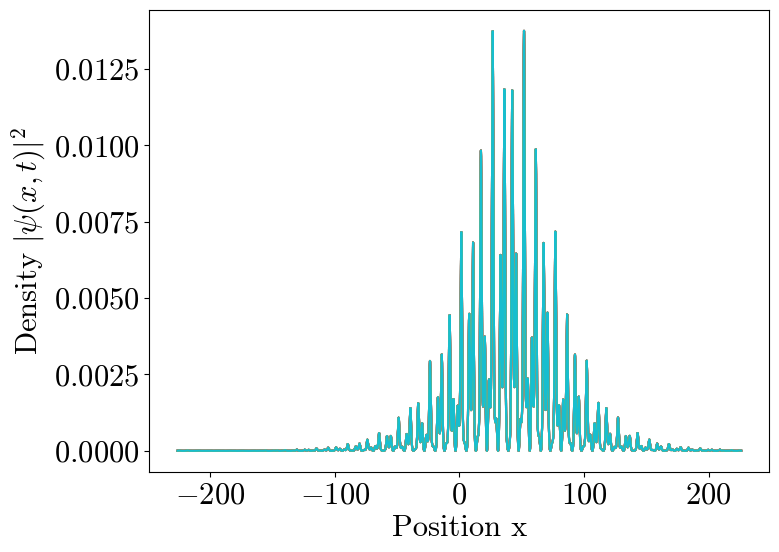

In [8]:
#onda = vectorsa[nx:,indice]
T = 100
nt = 100000

# Time evolution loop
psi = estados3[:,40]

psi_list = []
for j in range(nt):
    psi,const0 = evolucao(T,nt,nx,M,N,v1,v2,phi,psi)
    if j % 10000 == 0:  # Save some frames for visualization
        print(j,const0)
        psi_list.append(np.abs(psi)**2)

# Visualization: Plot the density of the wave function at different times
pl.figure(figsize=(8,6))
for i, psi_t in enumerate(psi_list):
    pl.plot(xx, psi_t)
    
pl.xlabel('Position x')
pl.ylabel('Density $|\psi(x,t)|^2$')
#pl.legend()
pl.show()

NameError: name 'history' is not defined

/usr/lib/python3/dist-packages/IPython/core/events.py:82: UserWarning: Glyph 968 (\N{GREEK SMALL LETTER PSI}) missing from current font.
  func(*args, **kwargs)
/usr/lib/python3/dist-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 968 (\N{GREEK SMALL LETTER PSI}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


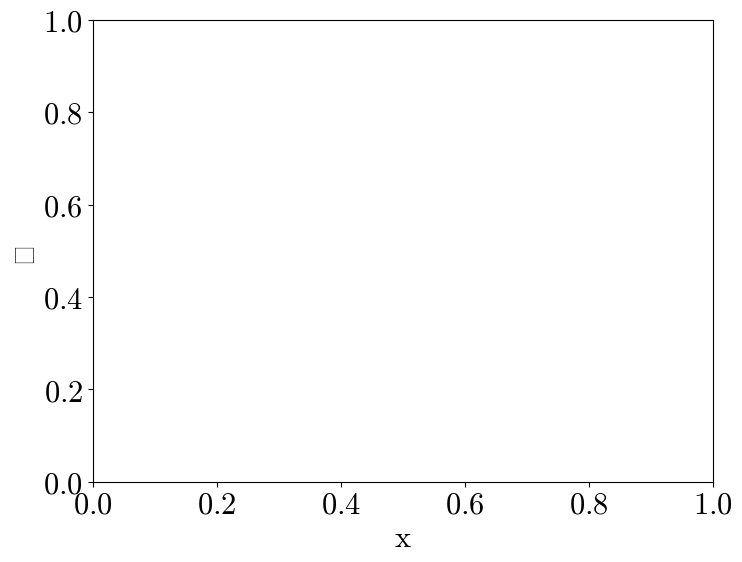

In [8]:
pl.figure(figsize=[8,6])
pl.rcParams['font.size'] = 22
pl.xlabel('x')
pl.ylabel('ψ')

for i in range(0,nt,nt//2):
    #pl.figure(figsize=[16,8])
#    pl.plot(xx,history[i].imag)
#    pl.plot(xx,history[i].real)
    #pl.plot(xx,np.sqrt(history[i].real**2+history[i].imag**2)-np.sqrt(estados[:,600].real**2+estados[:,600].imag**2))
    pl.plot(xx,history[i].real**2+history[i].imag**2,label=T*i//nt)
pl.plot(xx,history[-1].real**2+history[-1].imag**2,label=T)    
pl.legend()
    #pl.show()


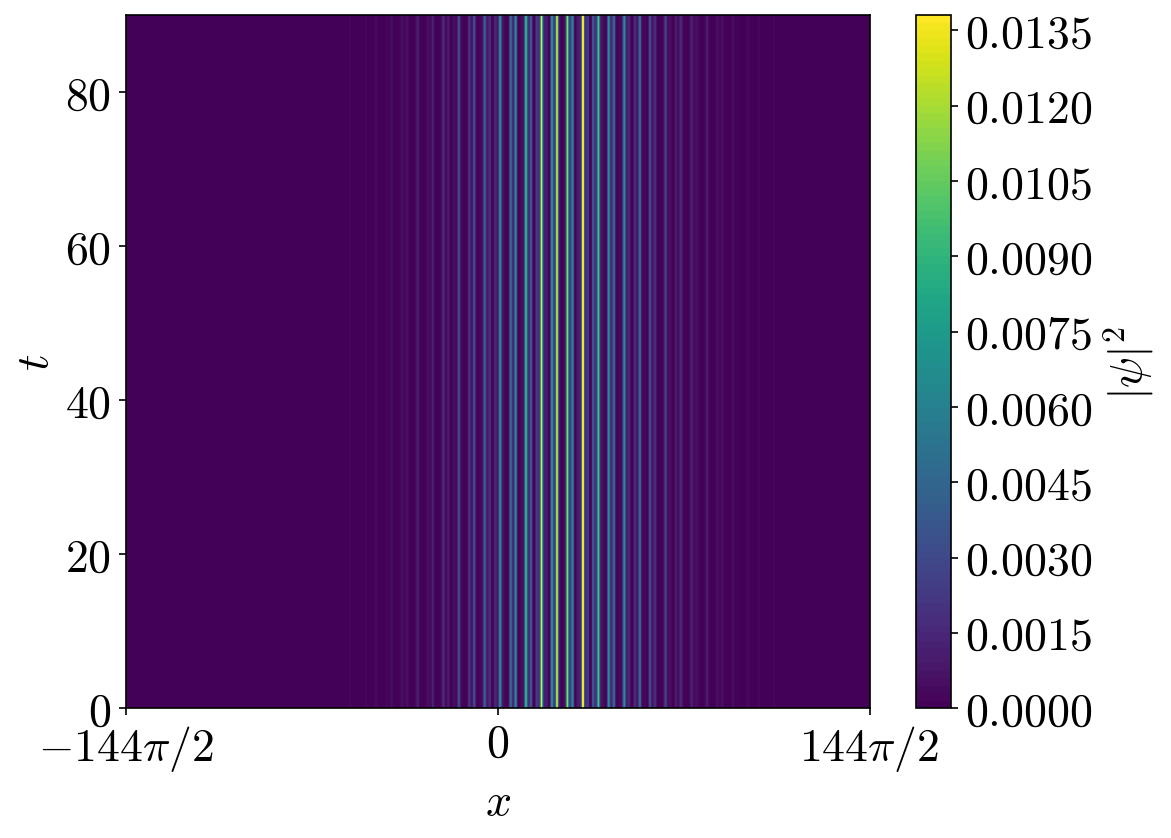

In [9]:
t = np.linspace(0,T,nt)
x,y = np.meshgrid(xx,t[::10000])
barras=(-144*np.pi/2,0,144*np.pi/2)
labels=(r'$-144\pi/2$','0',r'$144\pi/2$')


pl.rcParams['font.size'] = 22

pl.figure(figsize=[8,6],dpi=150)
#pl.contourf(x,y,history[::100,:].real**2+history[::100,:].imag**2,levels=100)
pl.contourf(x,y,psi_list,levels=100)
pl.xlabel('$x$')
pl.ylabel('$t$')
pl.xticks(barras,labels)
cbar = pl.colorbar()
cbar.set_label(r'$|\psi|^2$')

In [9]:
np.savetxt('evolucaorep89',psi_list)

In [ ]:
pl.figure(figsize=[8,6])
pl.xlim(-6,6)
pl.ylim(-0.001,0.001)
pl.xlabel(r'$\omega_{re}$')
pl.ylabel(r'$\omega_{im}$')
pl.scatter(valuesa.real,valuesa.imag,color='black',s=3)

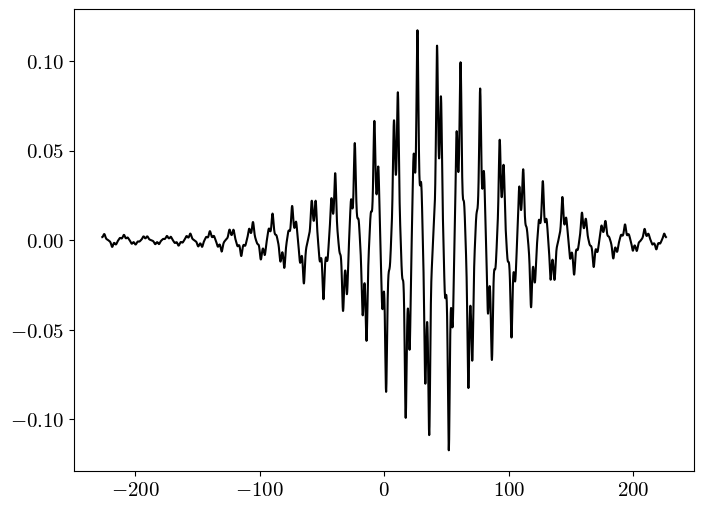

In [40]:
pl.figure(figsize=[8,6])
#pl.yscale('log')
pl.plot(xx,estados3[:,40],color='black')

In [11]:
fonaoloc = np.loadtxt('fonao54loc',dtype=complex)
fonaouloc = np.loadtxt('fonao54uloc',dtype=complex)
fonaodesloc = np.loadtxt('fonao54desloc',dtype=complex)

4856
4857
4911
5088
5142
5143


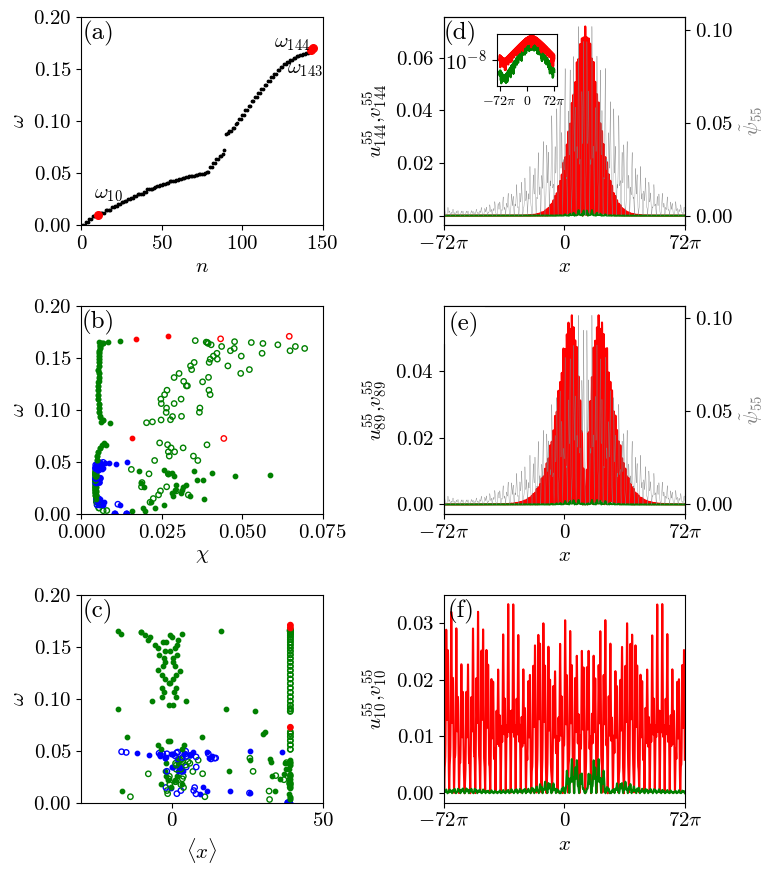

In [19]:
pl.rcParams['font.size'] = 15

indice1 = np.ravel(np.where(valuesa.real==sorted(valuesa.real)[4856]))[0]
indice2 = np.ravel(np.where(valuesa.real==sorted(valuesa.real)[5142]))[0]
indice3 = np.ravel(np.where(valuesa.real==sorted(valuesa.real)[5012]))[0]
barras=(-72*np.pi,0,72*np.pi)
labels=(r'$-72\pi$','0',r'$72\pi$')


fig = pl.figure(figsize=[8,9])

subfigs = fig.subplots(3,2)
subfigs[0,0].set_title("(a)",x=0.07,y=0.85)
subfigs[0,0].set_ylim(0,0.2)
subfigs[0,0].set_xlim(0,150)
subfigs[0,0].set_xlabel('$n$')
subfigs[0,0].set_ylabel(r'$\omega$')
subfigs[0,0].scatter(np.arange(0,10),sorted(valuesa)[4999:5009],color='black',s=3)
subfigs[0,0].scatter(np.arange(11,143),sorted(valuesa)[5010:5142],color='black',s=3)
subfigs[0,0].scatter(np.arange(145,150),sorted(valuesa)[5144:5149],color='black',s=3)
subfigs[0,0].scatter(10,sorted(valuesa)[5009],color='red',s=30)
subfigs[0,0].scatter(143,sorted(valuesa)[5142],color='red',s=30)
subfigs[0,0].scatter(144,sorted(valuesa)[5143],color='red',s=30)
subfigs[0,0].text(8,sorted(valuesa)[5030],r'$\omega_{10}$',fontsize=15)
subfigs[0,0].text(128,sorted(valuesa)[5120],r'$\omega_{143}$',fontsize=15)
subfigs[0,0].text(120,sorted(valuesa)[5143],r'$\omega_{144}$',fontsize=15)

subfigs[1,0].set_title("(b)", x=0.07, y=0.85)
subfigs[1,0].set_xlim(0,0.075)
subfigs[1,0].set_ylim(0,0.2)
subfigs[1,0].set_ylabel(r'$\omega$')
subfigs[1,0].set_xlabel(r'$\chi$')

deslocalizados = []
ulocalizado = []
vlocalizado = []
localizados = []

for i in range(4500,5500):
    if participacaou[i] > 0.015:
        if participacaov[i] > 0.015:
            subfigs[1,0].scatter(participacaou[i],sorted(valuesa)[i],color='red',s=10)
            subfigs[1,0].scatter(participacaov[i],sorted(valuesa)[i],color='red',s=15,edgecolors='red',facecolors='none')
            print(i)
            localizados.append(i)
        elif normu[i] > 10**(-6):
            subfigs[1,0].scatter(participacaou[i],sorted(valuesa)[i],color='green',s=10)
            subfigs[1,0].scatter(participacaov[i],sorted(valuesa)[i],color='green',s=15,edgecolors='green',facecolors='none')
            ulocalizado.append(i)
    elif participacaov[i] > 0.015: 
        if normv[i] > 10**(-6):
            subfigs[1,0].scatter(participacaou[i],sorted(valuesa)[i],color='green',s=10)
            subfigs[1,0].scatter(participacaov[i],sorted(valuesa)[i],color='green',s=15,edgecolors='green',facecolors='none')
            vlocalizado.append(i)
    else:
        subfigs[1,0].scatter(participacaou[i],sorted(valuesa)[i],color='blue',s=10)
        subfigs[1,0].scatter(participacaov[i],sorted(valuesa)[i],color='blue',s=15,edgecolors='blue',facecolors='none')
        deslocalizados.append(i)
        

subfigs[2,0].set_title("(c)", x=0.07, y=0.85)
subfigs[2,0].set_ylabel(r'$\omega$')
subfigs[2,0].set_xlabel(r'$\langle x \rangle$')
subfigs[2,0].set_ylim(0,0.2)
subfigs[2,0].set_xlim(-30,50)
indice = 4750
for i,j in enumerate(sorted(valuesa.real)[4750:5250]):
    nivel = np.ravel(np.where(valuesa==(sorted(valuesa)[indice])))
    u = vectorsa[0:nx,nivel[0]]
    v = vectorsa[nx:,nivel[0]]
    psiu = u.real**2+u.imag**2
    psiv = v.real**2+v.imag**2
    natomsu = (ht/3) * (psiu[0] + 2*sum(psiu[:nx-2:2]) + 4*sum(psiu[1:nx-1:2]) + psiu[nx-1])
    natomsv = (ht/3) * (psiv[0] + 2*sum(psiv[:nx-2:2]) + 4*sum(psiv[1:nx-1:2]) + psiv[nx-1])

    centrou = xx*psiu
    centrov = xx*psiv
    centrosu = (1/natomsu)*(ht/3)*(centrou[0] + 2*sum(centrou[:nx-2:2]) + 4*sum(centrou[1:nx-1:2]) + centrou[nx-1])
    centrosv = (1/natomsv)*(ht/3)*(centrov[0] + 2*sum(centrov[:nx-2:2]) + 4*sum(centrov[1:nx-1:2]) + centrov[nx-1])
    if indice in localizados:
        subfigs[2,0].scatter(centrosu,j,color='red',s=10)
        subfigs[2,0].scatter(centrosv,j,color='red',s=15,edgecolors='red',facecolors='none')
    elif indice in ulocalizado:
        subfigs[2,0].scatter(centrosu,j,color='green',s=10)
        subfigs[2,0].scatter(centrosv,j,color='green',s=15,edgecolors='green',facecolors='none')
    elif indice in vlocalizado:
        subfigs[2,0].scatter(centrosu,j,color='green',s=10)
        subfigs[2,0].scatter(centrosv,j,color='green',s=15,edgecolors='green',facecolors='none')
    elif indice in deslocalizados:
        subfigs[2,0].scatter(centrosu,j,color='blue',s=10)
        subfigs[2,0].scatter(centrosv,j,color='blue',s=15,edgecolors='blue',facecolors='none')
    indice+=1
    

subfigs[0,1].set_title("(d)", x=0.07, y=0.85)
inset = subfigs[0,1].inset_axes([0.22, 0.67, 0.25, 0.25])
subfigs[0,1].set_xlabel('$x$')
subfigs[0,1].set_ylabel('$u^{55}_{144}$,$v^{55}_{144}$')
subfigs[0,1].set_xticks(barras,labels)
subfigs[0,1].set_xlim(-72*np.pi,72*np.pi)

othery = subfigs[0,1].twinx()
othery.set_ylabel(r'$\tilde{\psi}_{55}$',color='gray')
othery.plot(xx,abs(estados3[:,30]),color='gray',linewidth=0.25)
othery.tick_params(axis='y')

subfigs[0,1].plot(xx,abs(vectorsa[nx:,indice1]),color='red')
subfigs[0,1].plot(xx,abs(vectorsa[0:nx,indice1]),color='green')

#subfigs[0,1].plot(xx,abs(fonaoloc[0:nx]),color='green')
#subfigs[0,1].plot(xx,abs(fonaoloc[nx:]),color='red')


inset.set_xticks(barras,labels,fontsize=10)
inset.set_yscale('log')

inset.plot(xx,abs(vectorsa[0:nx,indice1]),color='green')
inset.plot(xx,abs(vectorsa[nx:,indice1]),color='red')

#inset.plot(xx,abs(fonaoloc[0:nx]),color='green')
#inset.plot(xx,abs(fonaoloc[nx:]),color='red')

subfigs[1,1].set_title("(e)", x=0.082, y=0.84,backgroundcolor='white')
subfigs[1,1].set_xlabel('$x$')
subfigs[1,1].set_ylabel('$u^{55}_{89}$,$v^{55}_{89}$')
subfigs[1,1].set_xticks(barras,labels)
subfigs[1,1].set_xlim(-72*np.pi,72*np.pi)

othery = subfigs[1,1].twinx()
othery.set_ylabel(r'$\tilde{\psi}_{55}$',color='gray')
othery.plot(xx,abs(estados3[:,30]),color='gray',linewidth=0.25)
othery.tick_params(axis='y')

#subfigs[1,1].plot(xx,abs(estados3[:,30]),color='black',linewidth=0.5)
subfigs[1,1].plot(xx,abs(vectorsa[0:nx,indice2]),color='red')
subfigs[1,1].plot(xx,abs(vectorsa[nx:,indice2]),color='green')

#subfigs[1,1].plot(xx,abs(fonaouloc[0:nx]),color='red')
#subfigs[1,1].plot(xx,abs(fonaouloc[nx:]),color='green')

subfigs[2,1].set_title("(f)", x=0.07, y=0.85)
subfigs[2,1].set_xlabel('$x$')
subfigs[2,1].set_ylabel('$u^{55}_{10}$,$v^{55}_{10}$')
subfigs[2,1].set_xticks(barras,labels)
subfigs[2,1].set_xlim(-72*np.pi,72*np.pi)

subfigs[2,1].plot(xx,abs(vectorsa[nx:,indice3]),color='red')
subfigs[2,1].plot(xx,abs(vectorsa[0:nx,indice3]),color='green')

#subfigs[2,1].plot(xx,abs(fonaodesloc[0:nx]),color='green')
#subfigs[2,1].plot(xx,abs(fonaodesloc[nx:]),color='red')

pl.tight_layout()
pl.show()

In [69]:
valuesa2 = np.loadtxt('bdgatr53est',dtype=complex)
valuesa3 = np.loadtxt('bdgrep53est',dtype=complex)

<>:4: SyntaxWarning: invalid escape sequence '\o'
<>:5: SyntaxWarning: invalid escape sequence '\o'
<>:11: SyntaxWarning: invalid escape sequence '\o'
<>:12: SyntaxWarning: invalid escape sequence '\o'
<>:19: SyntaxWarning: invalid escape sequence '\o'
<>:20: SyntaxWarning: invalid escape sequence '\o'
<>:4: SyntaxWarning: invalid escape sequence '\o'
<>:5: SyntaxWarning: invalid escape sequence '\o'
<>:11: SyntaxWarning: invalid escape sequence '\o'
<>:12: SyntaxWarning: invalid escape sequence '\o'
<>:19: SyntaxWarning: invalid escape sequence '\o'
<>:20: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_4653/1138055407.py:4: SyntaxWarning: invalid escape sequence '\o'
  pl.xlabel('$\omega_{re}$')
/tmp/ipykernel_4653/1138055407.py:5: SyntaxWarning: invalid escape sequence '\o'
  pl.ylabel('$\omega_{im}$')
/tmp/ipykernel_4653/1138055407.py:11: SyntaxWarning: invalid escape sequence '\o'
  pl.xlabel('$\omega_{re}$')
/tmp/ipykernel_4653/1138055407.py:12: SyntaxWarning: invalid 

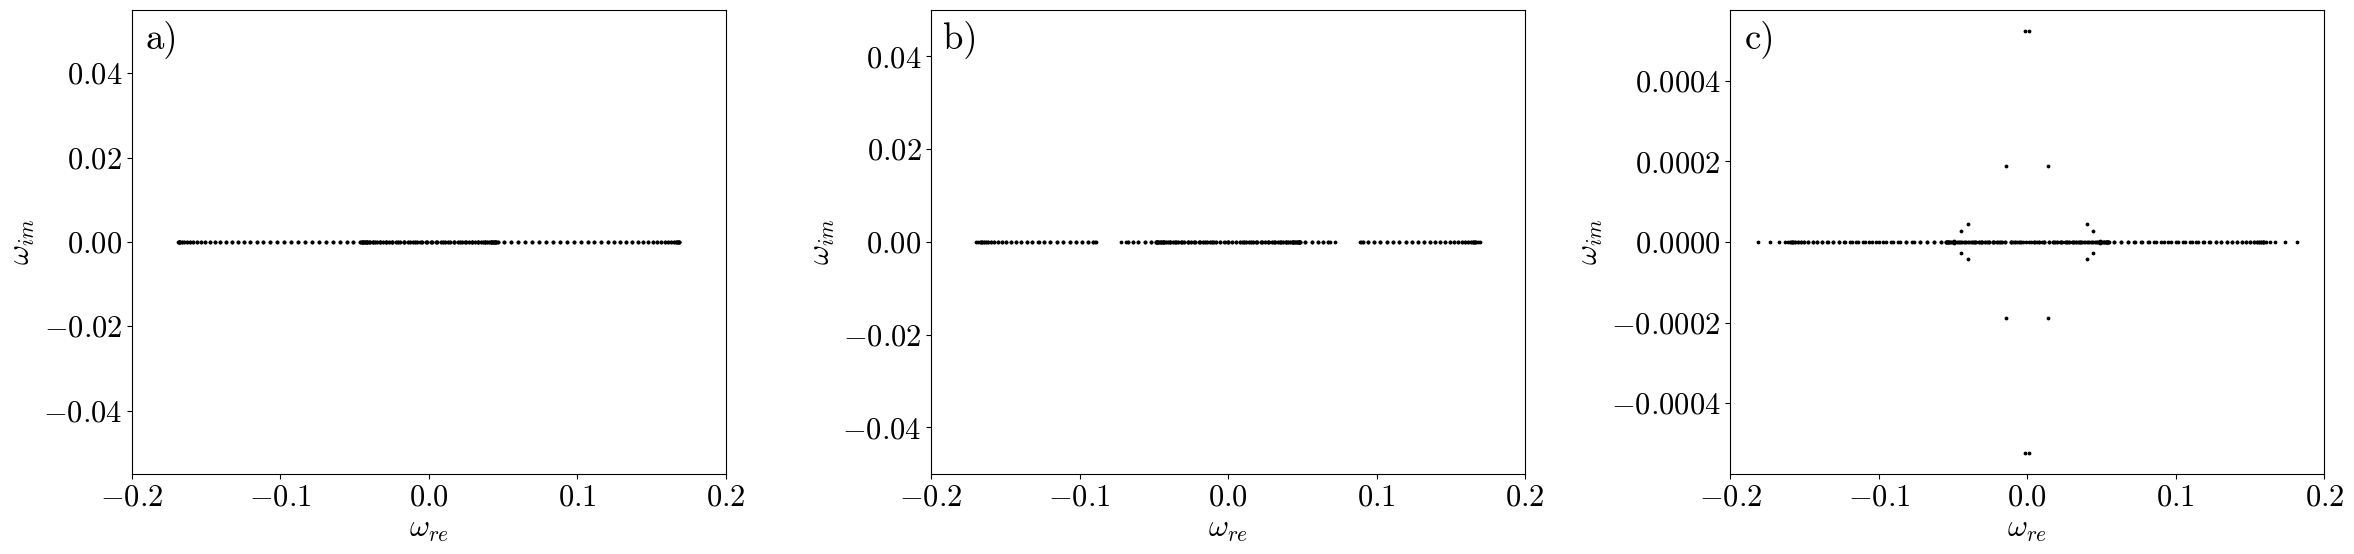

In [73]:
pl.figure(figsize=[24,6])
pl.subplot(1,3,1)
pl.title("a)", x=0.05, y=0.9)
pl.xlabel('$\omega_{re}$')
pl.ylabel('$\omega_{im}$')
pl.xlim(-0.2,0.2)
pl.scatter(valuesa2.real,valuesa2.imag,color='black',s=3)

pl.subplot(1,3,2)
pl.title("b)", x=0.05, y=0.9)
pl.xlabel('$\omega_{re}$')
pl.ylabel('$\omega_{im}$')
pl.xlim(-0.2,0.2)
pl.ylim(-0.05,0.05)
pl.scatter(valuesa3.real,valuesa3.imag,color='black',s=3)

pl.subplot(1,3,3)
pl.title("c)", x=0.05, y=0.9)
pl.xlabel('$\omega_{re}$')
pl.ylabel('$\omega_{im}$')
pl.xlim(-0.2,0.2)
pl.scatter(valuesa.real,valuesa.imag,color='black',s=3)
pl.tight_layout()

In [31]:
print(vlocalizado)

[4858, 4859, 4860, 4861, 4862, 4863, 4864, 4865, 4866, 4867, 4868, 4869, 4870, 4871, 4872, 4873, 4874, 4875, 4876, 4877, 4878, 4879, 4880, 4881, 4882, 4883, 4884, 4885, 4886, 4887, 4888, 4889, 4890, 4891, 4892, 4893, 4894, 4895, 4896, 4897, 4898, 4899, 4900, 4901, 4902, 4903, 4904, 4905, 4906, 4907, 4908, 4909, 4910, 4912, 4913, 4914, 4915, 4916, 4917, 4918, 4919, 4920, 4921, 4922, 4943, 4944, 4946, 4947, 4948, 4949, 4950, 4951, 4952, 4953, 4954, 4955, 4960, 4961, 4964, 4965, 4966, 4967, 4968, 4969, 4970, 4971, 4972, 4973, 4974, 4975, 4976, 4977, 4978, 4979, 4980, 4981, 4982, 4984, 4987, 4989, 4992, 4994, 4995, 4996, 4997, 5002, 5003, 5004, 5005, 5007, 5010, 5012, 5015, 5017, 5018, 5019, 5020, 5021, 5022, 5023, 5024, 5025, 5026, 5027, 5028, 5029, 5030, 5031, 5032, 5033, 5034, 5035, 5038, 5039, 5044, 5045, 5046, 5047, 5048, 5049, 5050, 5051, 5052, 5053, 5055, 5056, 5077, 5078, 5079, 5080, 5081, 5082, 5083, 5084, 5085, 5086, 5087, 5089, 5090, 5091, 5092, 5093, 5094, 5095, 5096, 5097, 509